# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [7]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

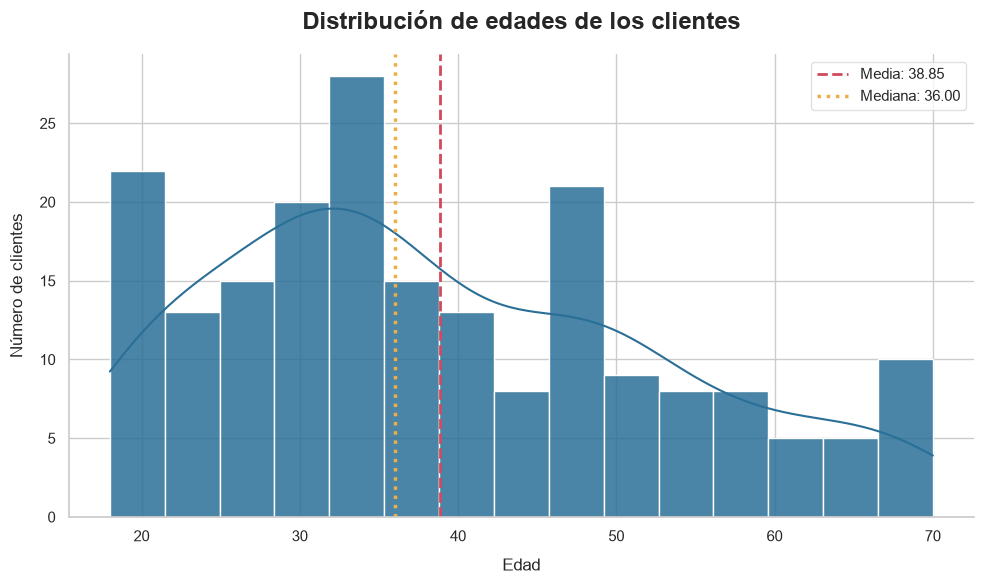

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('data/retailmax.csv')

sns.set_theme(style='whitegrid', context='notebook')
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=df,
    x='Age',
    bins=15,
    kde=True,
    color='#2A6F97',
    edgecolor='white',
    alpha=0.85,
    ax=ax
)
media = df['Age'].mean()
mediana = df['Age'].median()
ax.axvline(media, color='#D1495B', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
ax.axvline(mediana, color='#EDAE49', linestyle=':', linewidth=2.5, label=f'Mediana: {mediana:.2f}')
ax.set_title('Distribución de edades de los clientes', fontsize=17, fontweight='bold', pad=18)
ax.set_xlabel('Edad', fontsize=12, labelpad=10)
ax.set_ylabel('Número de clientes', fontsize=12, labelpad=10)
ax.legend(frameon=True, facecolor='white', edgecolor='#D9D9D9')
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

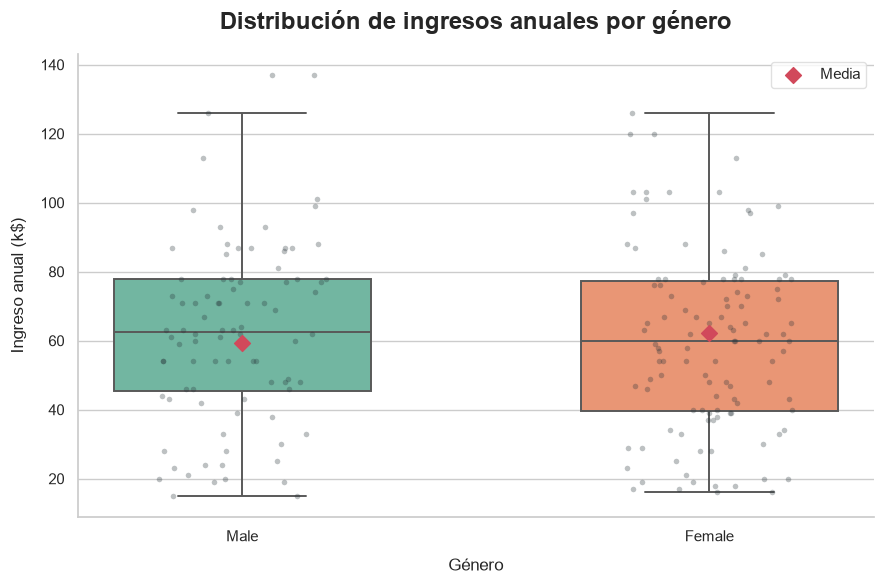

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('data/retailmax.csv')
ingreso = 'Annual Income (k$)'

sns.set_theme(style='whitegrid', context='notebook')
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(
    data=df,
    x='Gender',
    y=ingreso,
    hue='Gender',
    palette='Set2',
    width=0.55,
    linewidth=1.4,
    fliersize=0,
    legend=False,
    ax=ax
)
sns.stripplot(
    data=df,
    x='Gender',
    y=ingreso,
    color='#263238',
    alpha=0.3,
    size=4,
    jitter=0.18,
    ax=ax
)
medias = df.groupby('Gender', observed=True)[ingreso].mean()
for posicion, media in enumerate(medias):
    ax.scatter(posicion, media, color='#D1495B', marker='D', s=65, zorder=4, label='Media' if posicion == 0 else None)
ax.set_title('Distribución de ingresos anuales por género', fontsize=17, fontweight='bold', pad=18)
ax.set_xlabel('Género', fontsize=12, labelpad=10)
ax.set_ylabel('Ingreso anual (k$)', fontsize=12, labelpad=10)
ax.legend(frameon=True, facecolor='white', edgecolor='#D9D9D9')
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

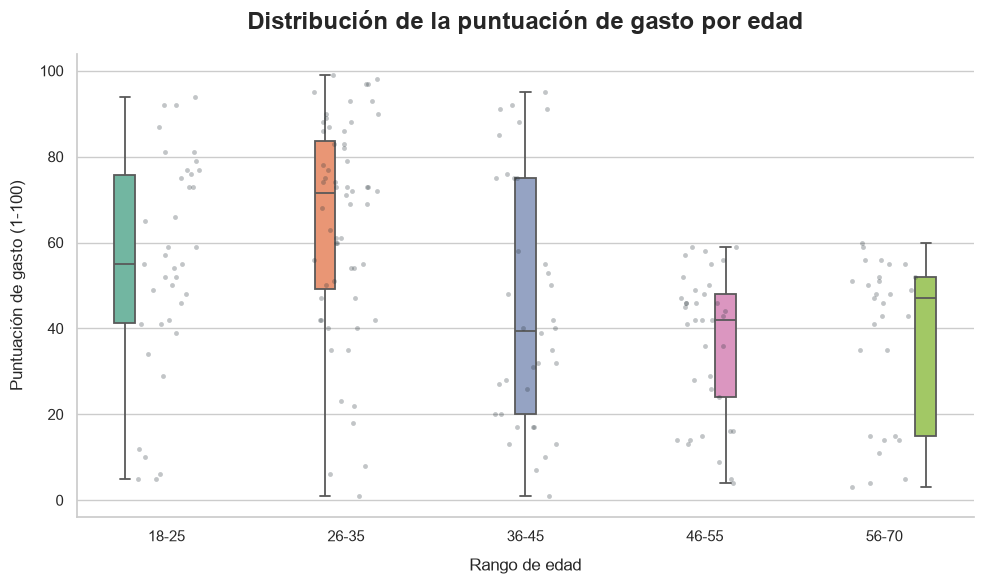

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('data/retailmax.csv')
rangos_edad = [18, 25, 35, 45, 55, 70]
etiquetas_edad = ['18-25', '26-35', '36-45', '46-55', '56-70']
df['Age Group'] = pd.cut(df['Age'], bins=rangos_edad, labels=etiquetas_edad, include_lowest=True)

sns.set_theme(style='whitegrid', context='notebook')
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Age Group',
    y='Spending Score (1-100)',
    hue='Age Group',
    palette='Set2',
    width=0.58,
    linewidth=1.3,
    fliersize=0,
    legend=False,
    ax=ax
)
sns.stripplot(
    data=df,
    x='Age Group',
    y='Spending Score (1-100)',
    color='#263238',
    alpha=0.28,
    size=3.5,
    jitter=0.18,
    ax=ax
)
ax.set_title('Distribución de la puntuación de gasto por edad', fontsize=17, fontweight='bold', pad=18)
ax.set_xlabel('Rango de edad', fontsize=12, labelpad=10)
ax.set_ylabel('Puntuación de gasto (1-100)', fontsize=12, labelpad=10)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

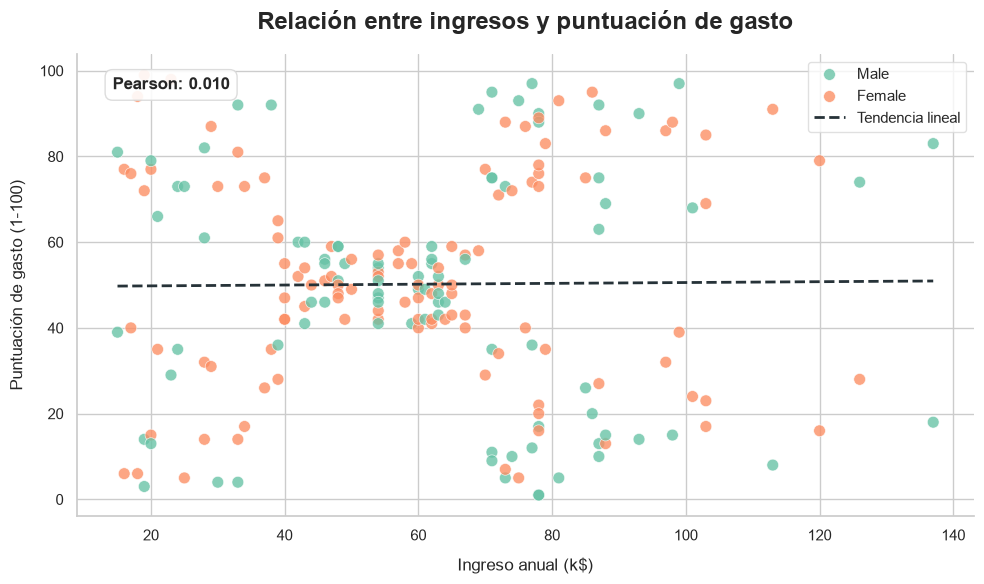

Coeficiente de correlación de Pearson: 0.010


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('data/retailmax.csv')
ingreso = 'Annual Income (k$)'
gasto = 'Spending Score (1-100)'
correlacion = df[ingreso].corr(df[gasto])
pendiente, intercepto = np.polyfit(df[ingreso], df[gasto], 1)
valores_x = np.linspace(df[ingreso].min(), df[ingreso].max(), 100)
valores_y = pendiente * valores_x + intercepto

sns.set_theme(style='whitegrid', context='notebook')
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x=ingreso,
    y=gasto,
    hue='Gender',
    palette='Set2',
    s=72,
    alpha=0.78,
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)
ax.plot(valores_x, valores_y, color='#263238', linestyle='--', linewidth=2, label='Tendencia lineal')
ax.set_title('Relación entre ingresos y puntuación de gasto', fontsize=17, fontweight='bold', pad=18)
ax.set_xlabel('Ingreso anual (k$)', fontsize=12, labelpad=10)
ax.set_ylabel('Puntuación de gasto (1-100)', fontsize=12, labelpad=10)
ax.text(
    0.04,
    0.95,
    f'Pearson: {correlacion:.3f}',
    transform=ax.transAxes,
    fontsize=12,
    fontweight='bold',
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.45', facecolor='white', edgecolor='#D9D9D9', alpha=0.9)
)
ax.legend(frameon=True, facecolor='white', edgecolor='#D9D9D9')
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

print(f'Coeficiente de correlación de Pearson: {correlacion:.3f}')

### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

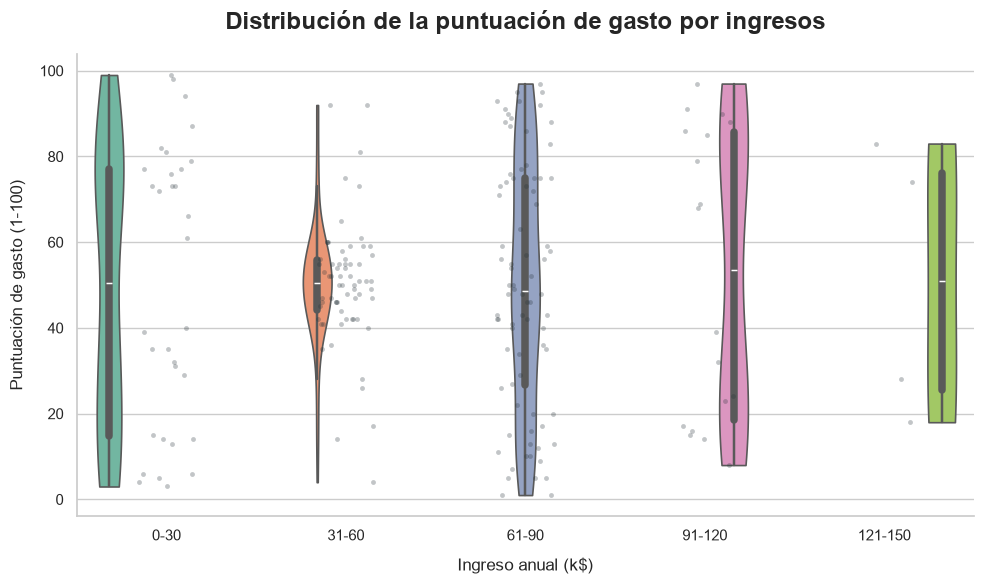

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('data/retailmax.csv')
ingreso = 'Annual Income (k$)'
gasto = 'Spending Score (1-100)'
rangos_ingreso = [0, 30, 60, 90, 120, 150]
etiquetas_ingreso = ['0-30', '31-60', '61-90', '91-120', '121-150']
df['Income Group'] = pd.cut(df[ingreso], bins=rangos_ingreso, labels=etiquetas_ingreso, include_lowest=True)

sns.set_theme(style='whitegrid', context='notebook')
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=df,
    x='Income Group',
    y=gasto,
    hue='Income Group',
    palette='Set2',
    inner='box',
    linewidth=1.2,
    cut=0,
    legend=False,
    ax=ax
)
sns.stripplot(
    data=df,
    x='Income Group',
    y=gasto,
    color='#263238',
    alpha=0.28,
    size=3.5,
    jitter=0.16,
    ax=ax
)
ax.set_title('Distribución de la puntuación de gasto por ingresos', fontsize=17, fontweight='bold', pad=18)
ax.set_xlabel('Ingreso anual (k$)', fontsize=12, labelpad=10)
ax.set_ylabel('Puntuación de gasto (1-100)', fontsize=12, labelpad=10)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

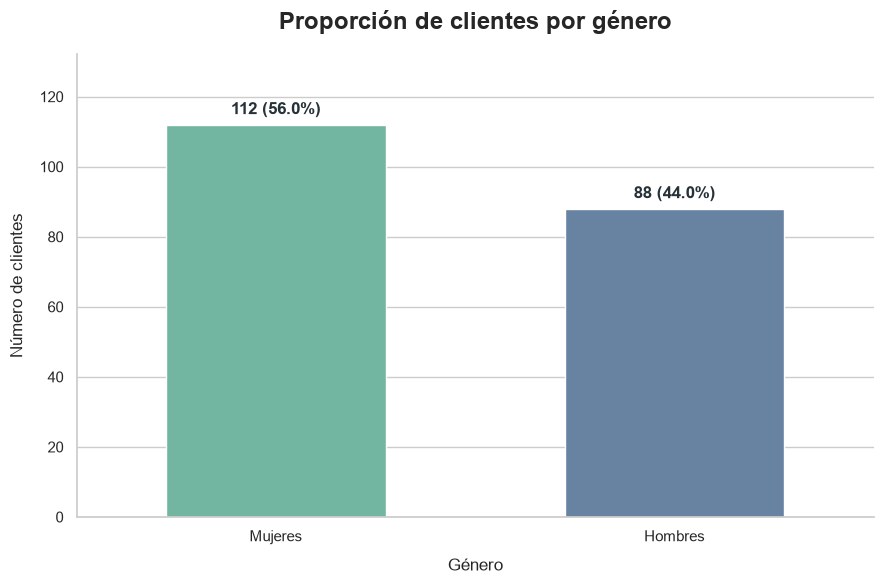

 Género  Clientes  Porcentaje
Mujeres       112        56.0
Hombres        88        44.0


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('data/retailmax.csv')

orden_genero = ['Female', 'Male']
etiquetas_genero = {'Female': 'Mujeres', 'Male': 'Hombres'}
conteos = (
    df['Gender']
    .value_counts()
    .reindex(orden_genero)
    .rename_axis('Gender')
    .reset_index(name='Clientes')
)
conteos['Género'] = conteos['Gender'].map(etiquetas_genero)
conteos['Porcentaje'] = conteos['Clientes'] / conteos['Clientes'].sum() * 100

sns.set_theme(style='whitegrid', context='notebook')
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=conteos,
    x='Género',
    y='Clientes',
    hue='Género',
    palette=['#66C2A5', '#5E81AC'],
    width=0.55,
    legend=False,
    ax=ax
)
for barra, clientes, porcentaje in zip(ax.patches, conteos['Clientes'], conteos['Porcentaje']):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 2,
        f'{clientes} ({porcentaje:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='#263238'
    )
ax.set_title('Proporción de clientes por género', fontsize=17, fontweight='bold', pad=18)
ax.set_xlabel('Género', fontsize=12, labelpad=10)
ax.set_ylabel('Número de clientes', fontsize=12, labelpad=10)
ax.set_ylim(0, conteos['Clientes'].max() * 1.18)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

print(conteos[['Género', 'Clientes', 'Porcentaje']].to_string(index=False))

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

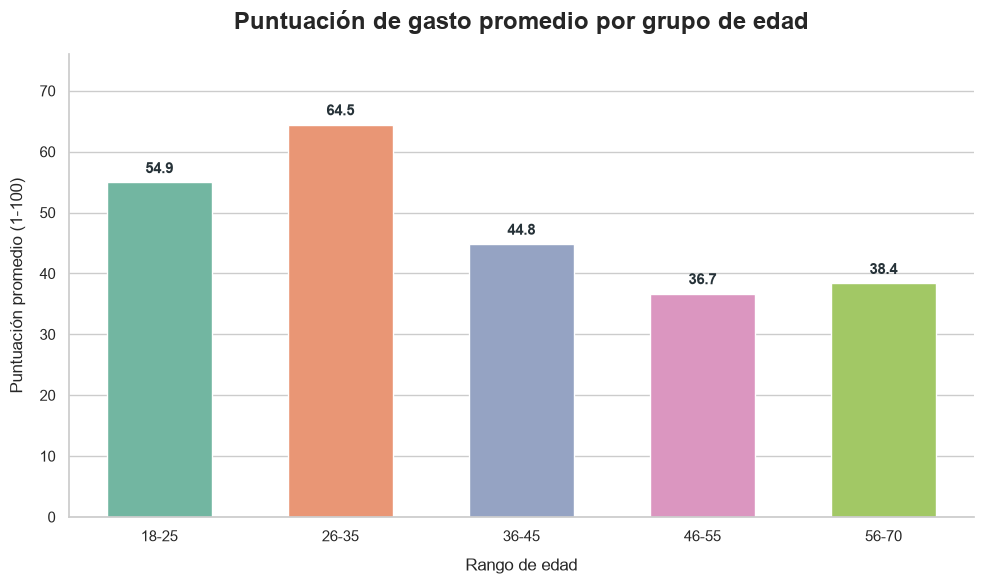

Age Group  Promedio
    18-25 54.947368
    26-35 64.450000
    36-45 44.833333
    46-55 36.702703
    56-70 38.379310


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('data/retailmax.csv')
rangos_edad = [18, 25, 35, 45, 55, 70]
etiquetas_edad = ['18-25', '26-35', '36-45', '46-55', '56-70']
df['Age Group'] = pd.cut(df['Age'], bins=rangos_edad, labels=etiquetas_edad, include_lowest=True)

gasto = 'Spending Score (1-100)'
promedios = (
    df.groupby('Age Group', observed=True)[gasto]
    .mean()
    .reindex(etiquetas_edad)
    .reset_index(name='Promedio')
)

sns.set_theme(style='whitegrid', context='notebook')
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=promedios,
    x='Age Group',
    y='Promedio',
    hue='Age Group',
    palette='Set2',
    width=0.58,
    legend=False,
    ax=ax
)
for barra, promedio in zip(ax.patches, promedios['Promedio']):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f'{promedio:.1f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='#263238'
    )
ax.set_title('Puntuación de gasto promedio por grupo de edad', fontsize=17, fontweight='bold', pad=18)
ax.set_xlabel('Rango de edad', fontsize=12, labelpad=10)
ax.set_ylabel('Puntuación promedio (1-100)', fontsize=12, labelpad=10)
ax.set_ylim(0, promedios['Promedio'].max() * 1.18)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

print(promedios.to_string(index=False))

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

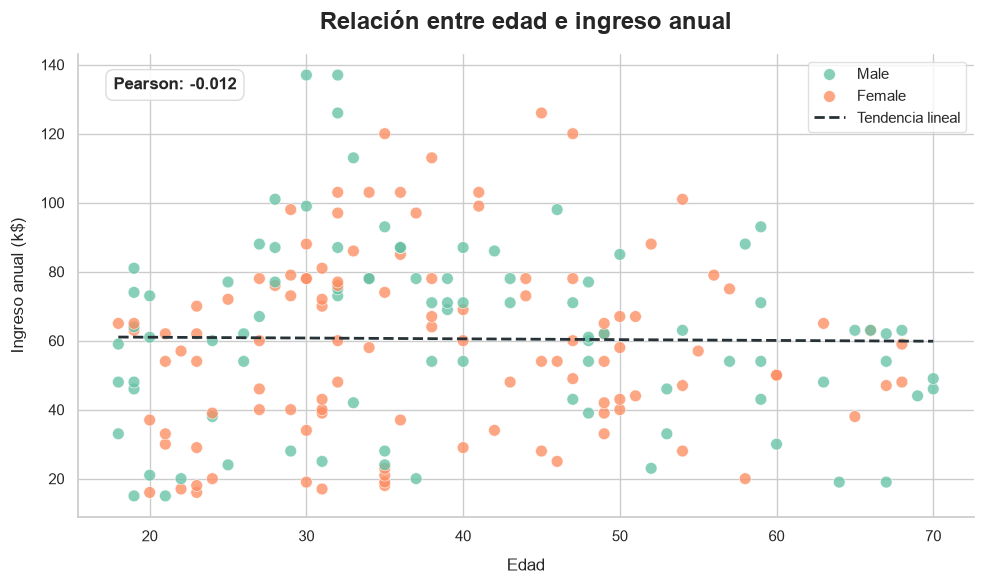

Coeficiente de correlación de Pearson: -0.012


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('data/retailmax.csv')
ingreso = 'Annual Income (k$)'
correlacion = df['Age'].corr(df[ingreso])
pendiente, intercepto = np.polyfit(df['Age'], df[ingreso], 1)
valores_x = np.linspace(df['Age'].min(), df['Age'].max(), 100)
valores_y = pendiente * valores_x + intercepto

sns.set_theme(style='whitegrid', context='notebook')
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Age',
    y=ingreso,
    hue='Gender',
    palette='Set2',
    s=72,
    alpha=0.78,
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)
ax.plot(valores_x, valores_y, color='#263238', linestyle='--', linewidth=2, label='Tendencia lineal')
ax.set_title('Relación entre edad e ingreso anual', fontsize=17, fontweight='bold', pad=18)
ax.set_xlabel('Edad', fontsize=12, labelpad=10)
ax.set_ylabel('Ingreso anual (k$)', fontsize=12, labelpad=10)
ax.text(
    0.04,
    0.95,
    f'Pearson: {correlacion:.3f}',
    transform=ax.transAxes,
    fontsize=12,
    fontweight='bold',
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.45', facecolor='white', edgecolor='#D9D9D9', alpha=0.9)
)
ax.legend(frameon=True, facecolor='white', edgecolor='#D9D9D9')
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

print(f'Coeficiente de correlación de Pearson: {correlacion:.3f}')

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

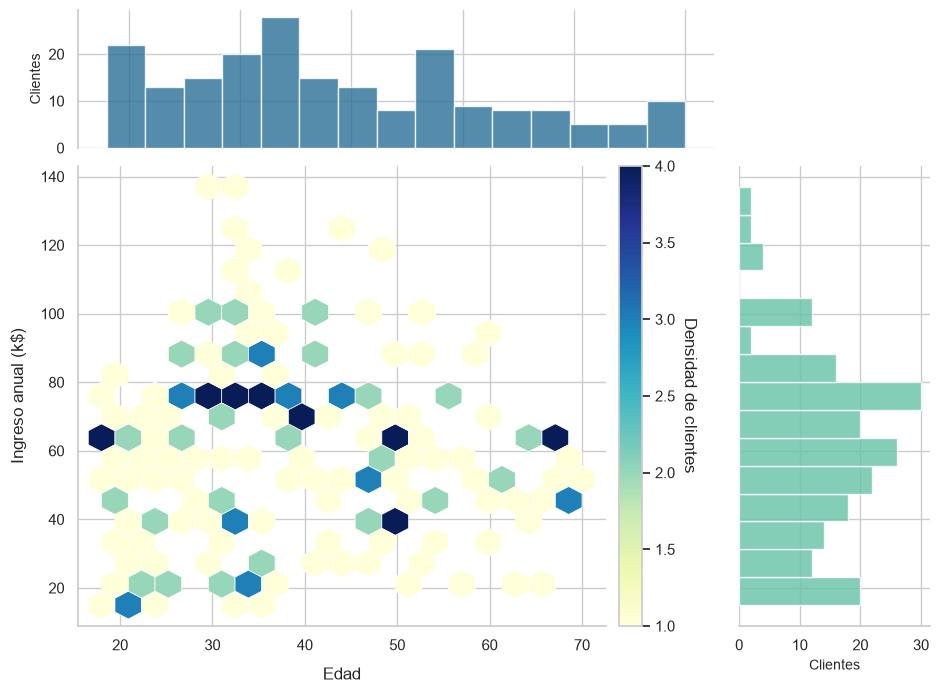

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('data/retailmax.csv')

sns.set_theme(style='whitegrid', context='notebook')
fig = plt.figure(figsize=(11, 8))
grid = fig.add_gridspec(
    2,
    2,
    width_ratios=(4, 1.2),
    height_ratios=(1.2, 4),
    hspace=0.06,
    wspace=0.06
)
ax_principal = fig.add_subplot(grid[1, 0])
ax_superior = fig.add_subplot(grid[0, 0], sharex=ax_principal)
ax_lateral = fig.add_subplot(grid[1, 1], sharey=ax_principal)

hexbin = ax_principal.hexbin(
    df['Age'],
    df['Annual Income (k$)'],
    gridsize=18,
    mincnt=1,
    cmap='YlGnBu',
    linewidths=0.5,
    edgecolors='white'
)
ax_principal.set_title('Distribución conjunta de edad e ingreso anual', fontsize=17, fontweight='bold', pad=18)
ax_principal.set_xlabel('Edad', fontsize=12, labelpad=10)
ax_principal.set_ylabel('Ingreso anual (k$)', fontsize=12, labelpad=10)

ax_superior.hist(df['Age'], bins=15, color='#2A6F97', alpha=0.8, edgecolor='white')
ax_lateral.hist(df['Annual Income (k$)'], bins=15, orientation='horizontal', color='#66C2A5', alpha=0.8, edgecolor='white')
ax_superior.tick_params(axis='x', labelbottom=False)
ax_lateral.tick_params(axis='y', labelleft=False)
ax_superior.set_ylabel('Clientes', fontsize=10)
ax_lateral.set_xlabel('Clientes', fontsize=10)

colorbar = fig.colorbar(hexbin, ax=ax_principal, pad=0.02)
colorbar.set_label('Densidad de clientes', rotation=270, labelpad=16)
sns.despine(ax=ax_superior, bottom=True)
sns.despine(ax=ax_lateral, left=True)
sns.despine(ax=ax_principal)
fig.tight_layout()
plt.show()

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

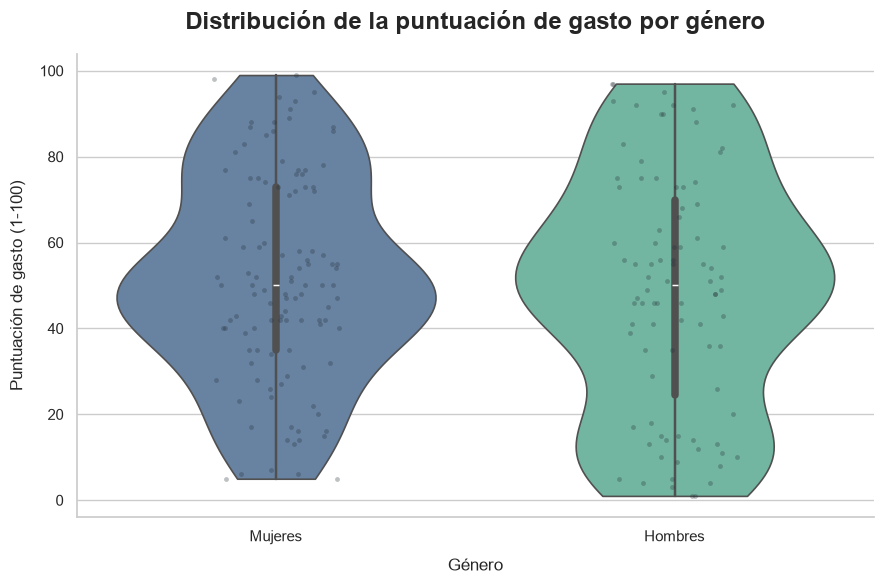

         count   mean  median
Género                       
Hombres     88  48.51    50.0
Mujeres    112  51.53    50.0


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('data/retailmax.csv')
gasto = 'Spending Score (1-100)'
orden_genero = ['Female', 'Male']
etiquetas_genero = {'Female': 'Mujeres', 'Male': 'Hombres'}
df['Género'] = df['Gender'].map(etiquetas_genero)

sns.set_theme(style='whitegrid', context='notebook')
fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(
    data=df,
    x='Género',
    y=gasto,
    order=['Mujeres', 'Hombres'],
    hue='Género',
    palette=['#66C2A5', '#5E81AC'],
    inner='box',
    linewidth=1.2,
    cut=0,
    legend=False,
    ax=ax
)
sns.stripplot(
    data=df,
    x='Género',
    y=gasto,
    order=['Mujeres', 'Hombres'],
    color='#263238',
    alpha=0.3,
    size=3.5,
    jitter=0.16,
    ax=ax
)
ax.set_title('Distribución de la puntuación de gasto por género', fontsize=17, fontweight='bold', pad=18)
ax.set_xlabel('Género', fontsize=12, labelpad=10)
ax.set_ylabel('Puntuación de gasto (1-100)', fontsize=12, labelpad=10)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

print(df.groupby('Género', observed=True)[gasto].agg(['count', 'mean', 'median']).round(2))